In [1]:
from dataclasses import replace

import matplotlib.pyplot as plt

from src.defects import make_y_path_masks
from src.morphology import compute_y_metrics
from src.config import SimulationConfig, WeakPathConfig

In [2]:
config = SimulationConfig(
    nx=128,
    ny=128,
    mean_breakdown_field=0.5,
    eta=1.5,
    correlation_length=5,
    weibull_shape=5.0,
    disorder_seed=7,
    random_seed=11,
    max_growth_steps=500,
    weak_path=WeakPathConfig(),
)
y_weak_path = replace(
    config.weak_path,
    kind="y",
    width=0.08,
    factor=0.6,
    start=(0.5, 0.1),
    branch_point=(0.5, 0.5),
    left_end=(0.25, 1.0),
    right_end=(0.75, 1.0),
    left_factor=0.6,
    right_factor=0.6,
)

y_config = replace(
    config,
    weak_path=y_weak_path,
)
y_masks = make_y_path_masks(y_config)

for name, mask in y_masks.items():
    print(
        f"{name}: "
        f"shape={mask.shape}, "
        f"dtype={mask.dtype}, "
        f"cells={mask.sum()}"
    )

trunk: shape=(128, 128), dtype=bool, cells=588
left: shape=(128, 128), dtype=bool, cells=744
right: shape=(128, 128), dtype=bool, cells=744
all: shape=(128, 128), dtype=bool, cells=1896


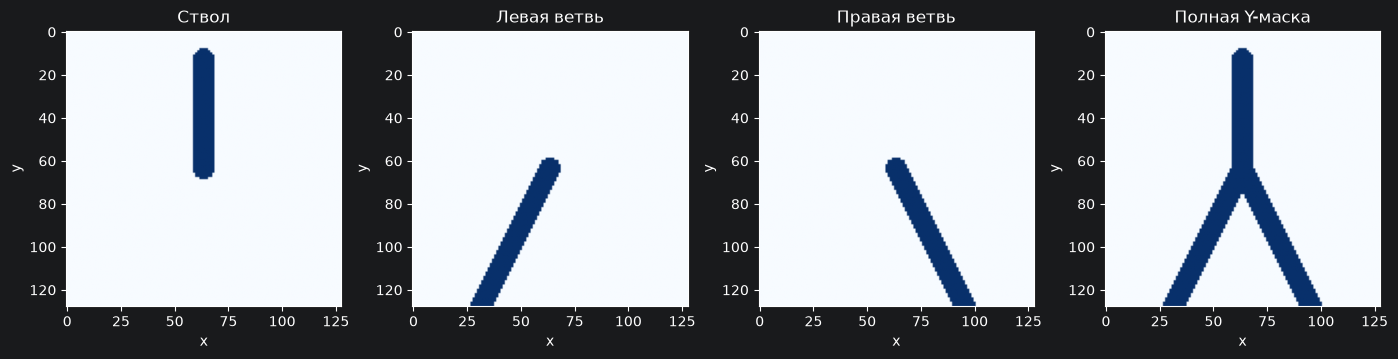

In [3]:
mask_names = [
    "trunk",
    "left",
    "right",
    "all",
]

mask_titles = [
    "Ствол",
    "Левая ветвь",
    "Правая ветвь",
    "Полная Y-маска",
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(14, 4),
)

for ax, name, title in zip(
    axes,
    mask_names,
    mask_titles,
):
    ax.imshow(
        y_masks[name],
        cmap="Blues",
        vmin=0,
        vmax=1,
    )

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

Все коэффициенты: [0.5  0.65 0.8  1.  ]
Ствол: [0.65]
Левая ветвь: [0.5]
Правая ветвь: [0.8]
Вне Y: [1.]


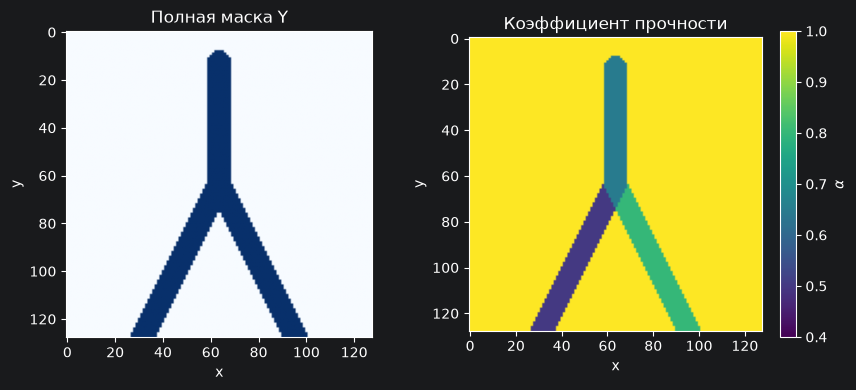

In [4]:
import numpy as np

from src.defects import (
    build_weak_path,
    make_y_path_masks,
)


test_weak_path = replace(
    y_config.weak_path,
    factor=0.65,
    left_factor=0.50,
    right_factor=0.80,
)

test_y_config = replace(
    y_config,
    weak_path=test_weak_path,
)

factor_map, full_y_mask = build_weak_path(
    test_y_config
)

test_masks = make_y_path_masks(
    test_y_config
)


trunk_only = (
    test_masks["trunk"]
    & ~test_masks["left"]
    & ~test_masks["right"]
)

left_only = (
    test_masks["left"]
    & ~test_masks["trunk"]
    & ~test_masks["right"]
)

right_only = (
    test_masks["right"]
    & ~test_masks["trunk"]
    & ~test_masks["left"]
)


print(
    "Все коэффициенты:",
    np.unique(factor_map),
)

print(
    "Ствол:",
    np.unique(factor_map[trunk_only]),
)

print(
    "Левая ветвь:",
    np.unique(factor_map[left_only]),
)

print(
    "Правая ветвь:",
    np.unique(factor_map[right_only]),
)

print(
    "Вне Y:",
    np.unique(factor_map[~full_y_mask]),
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
)

axes[0].imshow(
    full_y_mask,
    cmap="Blues",
    vmin=0,
    vmax=1,
)

axes[0].set_title("Полная маска Y")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

image = axes[1].imshow(
    factor_map,
    cmap="viridis",
    vmin=0.4,
    vmax=1.0,
)

axes[1].set_title("Коэффициент прочности")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

fig.colorbar(
    image,
    ax=axes[1],
    label=r"$\alpha$",
)

plt.tight_layout()
plt.show()

Число шагов: 500
Пробой: False
Клеток в стволе: 226
Клеток в левой ветви: 159
Клеток в правой ветви: 2
Индекс предпочтения: 0.9751552795031055


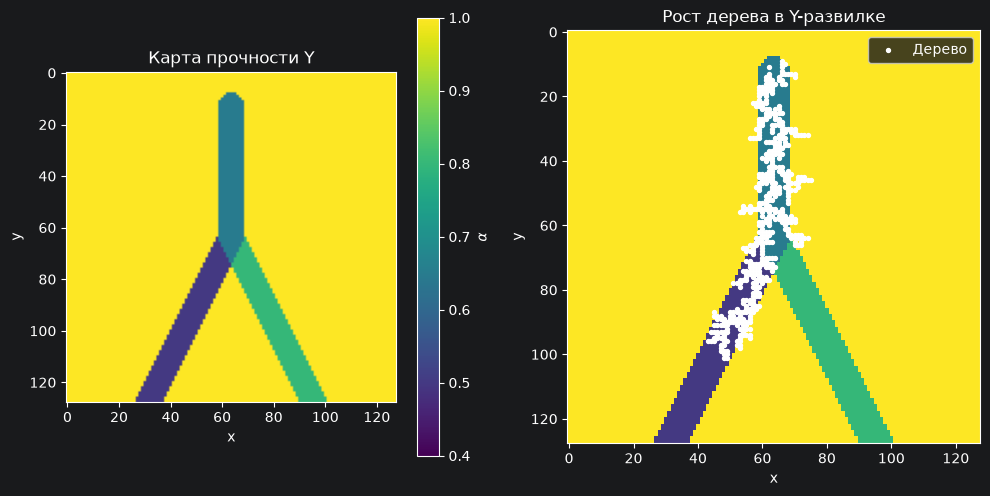

In [5]:
from src.simulator import run_simulation


field, history, breakdown = run_simulation(
    test_y_config
)

tree_mask = field.channel.copy()


trunk_cells = int(
    np.count_nonzero(
        tree_mask & trunk_only
    )
)

left_cells = int(
    np.count_nonzero(
        tree_mask & left_only
    )
)

right_cells = int(
    np.count_nonzero(
        tree_mask & right_only
    )
)

branch_cells = left_cells + right_cells

if branch_cells > 0:
    branch_preference = (
        left_cells - right_cells
    ) / branch_cells
else:
    branch_preference = np.nan


print("Число шагов:", len(history))
print("Пробой:", breakdown)
print("Клеток в стволе:", trunk_cells)
print("Клеток в левой ветви:", left_cells)
print("Клеток в правой ветви:", right_cells)
print("Индекс предпочтения:", branch_preference)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
)

image = axes[0].imshow(
    factor_map,
    cmap="viridis",
    vmin=0.4,
    vmax=1.0,
)

axes[0].set_title("Карта прочности Y")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

fig.colorbar(
    image,
    ax=axes[0],
    label=r"$\alpha$",
)


axes[1].imshow(
    factor_map,
    cmap="viridis",
    vmin=0.4,
    vmax=1.0,
)

tree_y, tree_x = np.where(tree_mask)

axes[1].scatter(
    tree_x,
    tree_y,
    s=8,
    color="white",
    label="Дерево",
)

axes[1].set_title("Рост дерева в Y-развилке")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
from src.defects import (
    build_weak_path,
    make_y_path_masks,
)

factor_map, full_y_mask = build_weak_path(
    test_y_config
)

y_masks = make_y_path_masks(
    test_y_config
)

trunk_mask = y_masks["trunk"]
left_mask = y_masks["left"]
right_mask = y_masks["right"]

branch_overlap = (
    left_mask
    & right_mask
)

trunk_and_junction = (
    trunk_mask
    | branch_overlap
)

left_only = (
    left_mask
    & ~trunk_and_junction
)

right_only = (
    right_mask
    & ~trunk_and_junction
)

outside_y = ~full_y_mask

print(
    "Ствол и развилка:",
    np.unique(factor_map[trunk_and_junction]),
)

print(
    "Левая ветвь:",
    np.unique(factor_map[left_only]),
)

print(
    "Правая ветвь:",
    np.unique(factor_map[right_only]),
)

print(
    "Вне Y:",
    np.unique(factor_map[outside_y]),
)

Ствол и развилка: [0.65]
Левая ветвь: [0.5]
Правая ветвь: [0.8]
Вне Y: [1.]


In [7]:
field, history, breakdown = run_simulation(
    test_y_config
)

y_masks = make_y_path_masks(
    test_y_config
)

y_metrics = compute_y_metrics(
    channel=field.channel,
    y_masks=y_masks,
)

print("Число шагов:", len(history))
print("Пробой:", breakdown)
print()

for name, value in y_metrics.items():
    if isinstance(value, (float, np.floating)):
        print(f"{name}: {value:.3f}")
    else:
        print(f"{name}: {value}")

Число шагов: 500
Пробой: False

tree_cells: 500
trunk_cells: 258
left_cells: 159
right_cells: 2
branch_cells: 161
y_cells: 419
outside_y_cells: 81
y_fraction: 0.838
left_branch_fraction: 0.988
right_branch_fraction: 0.012
branch_preference: 0.975
reached_fork: True


In [8]:
from dataclasses import replace


Y_CASES = {
    "symmetric": {
        "left_factor": 0.65,
        "right_factor": 0.65,
    },
    "left_weaker": {
        "left_factor": 0.50,
        "right_factor": 0.80,
    },
    "right_weaker": {
        "left_factor": 0.80,
        "right_factor": 0.50,
    },
}

N_Y_SEEDS = 20

Y_SEED_PAIRS = [
    (
        seed,
        10_000 + seed,
    )
    for seed in range(N_Y_SEEDS)
]

In [9]:
def run_single_y_case(
    base_config,
    case_name,
    left_factor,
    right_factor,
    disorder_seed,
    random_seed,
):
    weak_path = replace(
        base_config.weak_path,
        kind="y",
        left_factor=left_factor,
        right_factor=right_factor,
    )

    current_config = replace(
        base_config,
        weak_path=weak_path,
        disorder_seed=disorder_seed,
        random_seed=random_seed,
    )

    field, history, breakdown = run_simulation(
        current_config
    )

    current_y_masks = make_y_path_masks(
        current_config
    )

    metrics = compute_y_metrics(
        channel=field.channel,
        y_masks=current_y_masks,
    )

    return {
        "case": case_name,
        "left_factor": left_factor,
        "right_factor": right_factor,
        "disorder_seed": disorder_seed,
        "random_seed": random_seed,
        "steps": len(history),
        "breakdown": breakdown,
        **metrics,
    }

In [10]:
from joblib import Parallel, delayed
import pandas as pd


y_records = Parallel(
    n_jobs=-1,
    verbose=10,
)(
    delayed(run_single_y_case)(
        base_config=test_y_config,
        case_name=case_name,
        left_factor=case_parameters["left_factor"],
        right_factor=case_parameters["right_factor"],
        disorder_seed=disorder_seed,
        random_seed=random_seed,
    )
    for case_name, case_parameters in Y_CASES.items()
    for disorder_seed, random_seed in Y_SEED_PAIRS
)

y_results = pd.DataFrame(
    y_records
)

print(
    "Ожидалось запусков:",
    len(Y_CASES) * len(Y_SEED_PAIRS),
)

print(
    "Получено запусков:",
    len(y_results),
)

print(
    "Размер таблицы:",
    y_results.shape,
)

y_results.head(10)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   18.8s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done  44 out of  60 | elapsed:   29.0s remaining:   10.6s
[Parallel(n_jobs=-1)]: Done  51 out of  60 | elapsed:   30.6s remaining:    5.4s
[Parallel(n_jobs=-1)]: Done  58 out of  60 | elapsed:   34.7s remaining:    1.2s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:   34.9s finished


Ожидалось запусков: 60
Получено запусков: 60
Размер таблицы: (60, 19)


,case,left_factor,right_factor,disorder_seed,random_seed,steps,breakdown,tree_cells,trunk_cells,left_cells,right_cells,branch_cells,y_cells,outside_y_cells,y_fraction,left_branch_fraction,right_branch_fraction,branch_preference,reached_fork
0,symmetric,0.65,0.65,0,10000,500,False,500,258,137,23,160,418,82,0.836,0.856250,0.143750,0.712500,True
1,symmetric,0.65,0.65,1,10001,500,False,500,202,23,103,126,328,172,0.656,0.182540,0.817460,-0.634921,True
2,symmetric,0.65,0.65,2,10002,500,False,500,263,20,116,136,399,101,0.798,0.147059,0.852941,-0.705882,True
3,symmetric,0.65,0.65,3,10003,500,False,500,214,81,53,134,348,152,0.696,0.604478,0.395522,0.208955,True
4,symmetric,0.65,0.65,4,10004,500,False,500,218,132,14,146,364,136,0.728,0.904110,0.095890,0.808219,True
5,symmetric,0.65,0.65,5,10005,500,False,500,239,32,150,182,421,79,0.842,0.175824,0.824176,-0.648352,True
6,symmetric,0.65,0.65,6,10006,500,False,500,210,119,19,138,348,152,0.696,0.862319,0.137681,0.724638,True
7,symmetric,0.65,0.65,7,10007,500,False,500,230,1,175,176,406,94,0.812,0.005682,0.994318,-0.988636,True
8,symmetric,0.65,0.65,8,10008,500,False,500,227,35,139,174,401,99,0.802,0.201149,0.798851,-0.597701,True
9,symmetric,0.65,0.65,9,10009,500,False,500,220,29,147,176,396,104,0.792,0.164773,0.835227,-0.670455,True


In [11]:
case_order = [
    "symmetric",
    "left_weaker",
    "right_weaker",
]

y_summary = (
    y_results
    .groupby("case")
    .agg(
        n_runs=(
            "case",
            "size",
        ),
        n_reached_fork=(
            "reached_fork",
            "sum",
        ),
        p_reached_fork=(
            "reached_fork",
            "mean",
        ),
        mean_y_fraction=(
            "y_fraction",
            "mean",
        ),
        mean_preference=(
            "branch_preference",
            "mean",
        ),
        median_preference=(
            "branch_preference",
            "median",
        ),
        std_preference=(
            "branch_preference",
            "std",
        ),
        p_breakdown=(
            "breakdown",
            "mean",
        ),
    )
    .reindex(case_order)
    .reset_index()
)

y_summary.round(3)

,case,n_runs,n_reached_fork,p_reached_fork,mean_y_fraction,mean_preference,median_preference,std_preference,p_breakdown
0,symmetric,20,20,1.0,0.775,-0.069,-0.294,0.679,0.0
1,left_weaker,20,20,1.0,0.800,0.547,0.766,0.501,0.0
2,right_weaker,20,20,1.0,0.800,-0.604,-0.780,0.487,0.0


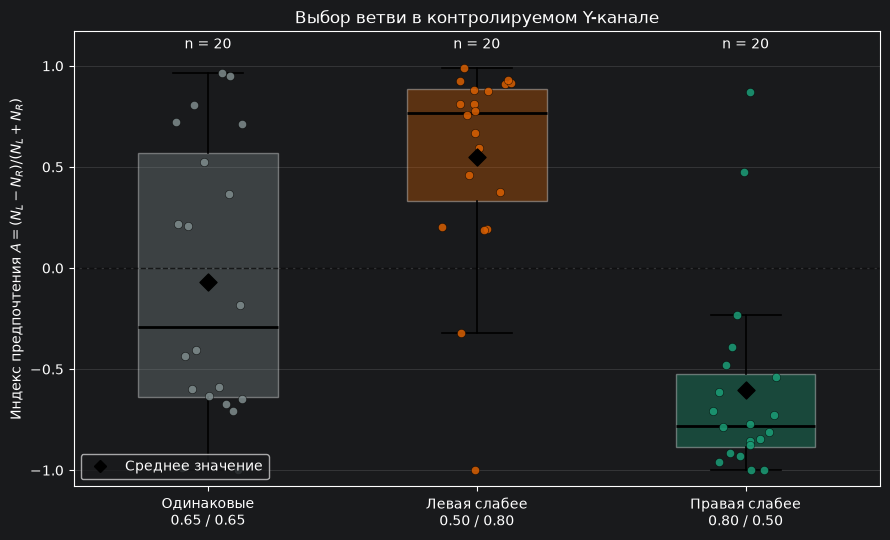

In [12]:
from pathlib import Path
from matplotlib.lines import Line2D


case_order = [
    "symmetric",
    "left_weaker",
    "right_weaker",
]

case_labels = {
    "symmetric": "Одинаковые\n0.65 / 0.65",
    "left_weaker": "Левая слабее\n0.50 / 0.80",
    "right_weaker": "Правая слабее\n0.80 / 0.50",
}

case_colors = {
    "symmetric": "#7f8c8d",
    "left_weaker": "#d95f02",
    "right_weaker": "#1b9e77",
}

valid_y_results = y_results.loc[
    y_results["reached_fork"].astype(bool)
    & np.isfinite(y_results["branch_preference"])
].copy()


missing_cases = [
    case_name
    for case_name in case_order
    if valid_y_results.loc[
        valid_y_results["case"] == case_name
    ].empty
]

if missing_cases:
    raise RuntimeError(
        "Нет деревьев, дошедших до развилки, "
        f"для случаев: {missing_cases}"
    )


positions = np.arange(
    1,
    len(case_order) + 1,
)

plot_data = [
    valid_y_results.loc[
        valid_y_results["case"] == case_name,
        "branch_preference",
    ].to_numpy()
    for case_name in case_order
]


fig, ax = plt.subplots(
    figsize=(9, 5.5),
)

boxplot = ax.boxplot(
    plot_data,
    positions=positions,
    widths=0.52,
    patch_artist=True,
    showfliers=False,
    medianprops={
        "color": "black",
        "linewidth": 2,
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.2,
    },
    capprops={
        "color": "black",
        "linewidth": 1.2,
    },
)

for patch, case_name in zip(
    boxplot["boxes"],
    case_order,
):
    patch.set_facecolor(
        case_colors[case_name]
    )
    patch.set_alpha(0.35)


rng = np.random.default_rng(20260923)

for position, case_name, values in zip(
    positions,
    case_order,
    plot_data,
):
    jitter = rng.uniform(
        -0.13,
        0.13,
        size=len(values),
    )

    ax.scatter(
        position + jitter,
        values,
        s=35,
        color=case_colors[case_name],
        edgecolor="black",
        linewidth=0.35,
        alpha=0.85,
        zorder=3,
    )

    ax.scatter(
        position,
        np.mean(values),
        marker="D",
        s=75,
        color="black",
        zorder=4,
    )

    ax.text(
        position,
        1.07,
        f"n = {len(values)}",
        ha="center",
        va="bottom",
        fontsize=10,
    )


ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_xticks(
    positions,
    [case_labels[name] for name in case_order],
)

ax.set_yticks(
    [-1.0, -0.5, 0.0, 0.5, 1.0]
)

ax.set_ylim(
    -1.08,
    1.17,
)

ax.set_ylabel(
    r"Индекс предпочтения "
    r"$A=(N_L-N_R)/(N_L+N_R)$"
)

ax.set_title(
    "Выбор ветви в контролируемом Y-канале"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="D",
            linestyle="none",
            markerfacecolor="black",
            markeredgecolor="black",
            label="Среднее значение",
        )
    ],
    loc="lower left",
)

Path("figures").mkdir(
    exist_ok=True
)

plt.tight_layout()

plt.savefig(
    "figures/y_branch_preference.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

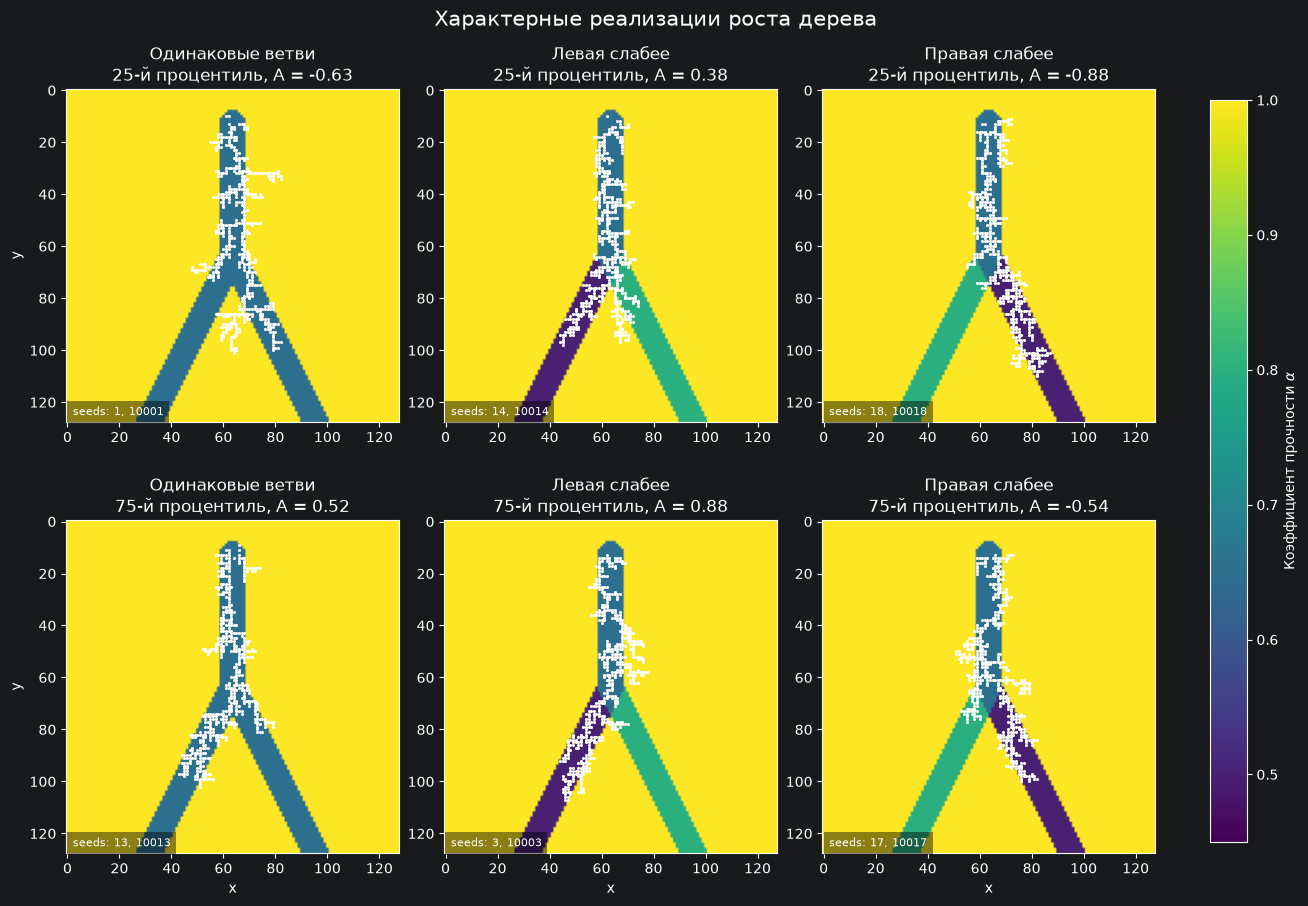

In [13]:
quantiles = [
    (0.25, "25-й процентиль"),
    (0.75, "75-й процентиль"),
]

column_titles = {
    "symmetric": "Одинаковые ветви",
    "left_weaker": "Левая слабее",
    "right_weaker": "Правая слабее",
}


fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13, 9),
    constrained_layout=True,
)

last_image = None


for column_index, case_name in enumerate(
    case_order
):
    case_rows = (
        valid_y_results.loc[
            valid_y_results["case"] == case_name
        ]
        .copy()
    )

    used_indices = set()

    for row_index, (
        quantile,
        quantile_name,
    ) in enumerate(quantiles):
        target_preference = (
            case_rows["branch_preference"]
            .quantile(quantile)
        )

        distances = (
            case_rows["branch_preference"]
            .sub(target_preference)
            .abs()
            .sort_values()
        )

        selected_index = next(
            index
            for index in distances.index
            if index not in used_indices
        )

        used_indices.add(selected_index)

        record = case_rows.loc[
            selected_index
        ]

        current_weak_path = replace(
            test_y_config.weak_path,
            kind="y",
            left_factor=float(
                record["left_factor"]
            ),
            right_factor=float(
                record["right_factor"]
            ),
        )

        current_config = replace(
            test_y_config,
            weak_path=current_weak_path,
            disorder_seed=int(
                record["disorder_seed"]
            ),
            random_seed=int(
                record["random_seed"]
            ),
        )

        field, history, breakdown = (
            run_simulation(current_config)
        )

        current_factor_map, _ = (
            build_weak_path(current_config)
        )

        ax = axes[
            row_index,
            column_index,
        ]

        last_image = ax.imshow(
            current_factor_map,
            cmap="viridis",
            vmin=0.45,
            vmax=1.0,
        )

        tree_y, tree_x = np.where(
            field.channel
        )

        ax.scatter(
            tree_x,
            tree_y,
            s=5,
            color="white",
            linewidths=0,
        )

        ax.set_title(
            f"{column_titles[case_name]}\n"
            f"{quantile_name}, "
            f"A = "
            f"{record['branch_preference']:.2f}"
        )

        if row_index == 1:
            ax.set_xlabel("x")

        if column_index == 0:
            ax.set_ylabel("y")

        ax.text(
            0.02,
            0.02,
            "seeds: "
            f"{int(record['disorder_seed'])}, "
            f"{int(record['random_seed'])}",
            transform=ax.transAxes,
            fontsize=8,
            color="white",
            bbox={
                "facecolor": "black",
                "alpha": 0.45,
                "edgecolor": "none",
            },
        )


fig.colorbar(
    last_image,
    ax=axes.ravel().tolist(),
    shrink=0.88,
    label=r"Коэффициент прочности $\alpha$",
)

fig.suptitle(
    "Характерные реализации роста дерева",
    fontsize=15,
)

fig.savefig(
    "figures/y_representative_trees.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Вывод по контролируемой Y-развилке

При одинаковой прочности ветвей отдельные реализации могут выбирать
как левую, так и правую сторону: значения индекса предпочтения около
25-го и 75-го процентилей равны соответственно \(A=-0.63\) и
\(A=0.52\). Следовательно, выбор ветви в отдельном запуске остаётся
случайным. Для оценки систематического смещения необходимо использовать
среднее значение по всей серии запусков.

При ослаблении левой ветви оба показанных значения положительны:
\(A=0.38\) и \(A=0.88\). Даже реализация около нижнего квартиля
содержит примерно \(69\%\) клеток ветвей слева. Поскольку уже
\(Q_{25}>0\), большинство реализаций предпочитает более слабую левую
ветвь.

При зеркальной перестановке коэффициентов индекс становится
отрицательным: \(A=-0.88\) и \(A=-0.54\). В этих реализациях в более
слабой правой ветви находится примерно \(94\%\) и \(77\%\) клеток
соответственно. Таким образом, изменение знака асимметрии прочности
изменяет и направление преимущественного роста.

Дерево не ограничено границами заданного Y-канала: некоторые клетки
выходят за его пределы вследствие случайной неоднородности материала и
распределения электрического поля. Поэтому слабый канал направляет рост,
но не задаёт его жёсткую траекторию.

Эксперимент подтверждает физически ожидаемое поведение модели:
электрическое дерево статистически предпочитает область с меньшей
электрической прочностью, причём при зеркальной перестановке параметров
предпочтение ветви также меняется зеркально.

In [15]:
from pathlib import Path

final_y_summary = (
    y_results
    .groupby("case")
    .agg(
        n_runs=("case", "size"),
        n_reached_fork=("reached_fork", "sum"),
        mean_y_fraction=("y_fraction", "mean"),
        mean_preference=("branch_preference", "mean"),
        median_preference=("branch_preference", "median"),
    )
    .reindex([
        "symmetric",
        "left_weaker",
        "right_weaker",
    ])
)

final_y_summary.round(3)
output_dir = Path(
    "results/controlled_y"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

y_results.to_csv(
    output_dir / "y_all_runs.csv",
    index=False,
)

final_y_summary.reset_index().to_csv(
    output_dir / "y_summary.csv",
    index=False,
)

print(
    "Сохранено:",
    output_dir.resolve(),
)

Сохранено: /home/artur/PycharmProjects/Mathprac/notebooks/results/controlled_y
